In [1]:
#!/usr/bin/env python3

import sys
import numpy as np
import cv2
import matplotlib.pyplot as plt
from typing import List

IMAGE_NAME = "../images/parrot.png"
YIQ_CONVERTER_MATRIX = np.array([[0.299,0.587,0.114],[0.596, -0.275, -0.321],[0.212, -0.523, 0.311]],dtype=np.float32)


In [2]:

#4.1
def imReadAndConvert(filename: str, representation: int) -> np.ndarray:
    """
    Reads an image, and returns the image converted as requested

    Args:
        filename (str): Path to the image
        representation (int): grayscale(1) or RGB(2)

    Returns:
        np.ndarray: The image np array
    """
    img = cv2.imread(filename)
    if img is None:
        print("File name is invalid")
        return np.array([])

    if representation == 1:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        return gray.astype(np.float32) / 255.0

    if representation == 2:
        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return rgb.astype(np.float32) / 255.0

    print("Invalid Representation Value")
    return np.array([])


In [3]:
img = imReadAndConvert(IMAGE_NAME, 2)

In [4]:

# 4.2

def imDisplay(filename:str, representation:int)-> None:
	"""Reads an image as RGB or GRAY_SCALE and displays it

	Args:
		filename (str): The path to the image
		representation (int): grayscale(1) or RGB(2)
	"""
	img = cv2.imread(filename)
	if img is not None:
		plt.figure(f"{filename}")
		match(representation):
			case 1:
				plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), cmap="gray")
			case 2:
				plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
			case _:
				print("Invalid representation!")
				return
		plt.show()
		return
	else:
		print("Invalid file name")
		return


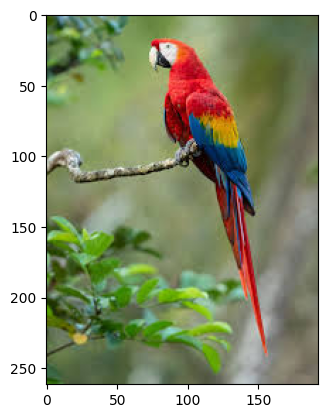

In [5]:
imDisplay(IMAGE_NAME,2)

In [6]:

# 4.3

def transformRGB2YIQ(imRGB:np.ndarray)->np.ndarray:
	"""Converts an RGB to YIQ color space

	Args:
		imRGB (np.ndarray): An Image in RGB

	Returns:
		np.ndarray: A YIQ in image color space
	"""
	if(imRGB.ndim != 3 or imRGB.shape[2] != 3):
		print("Invalid image shape")
		return imRGB
	new_img = imRGB@YIQ_CONVERTER_MATRIX
	return np.clip(new_img,0,1)

def transformYIQ2RGB(imYIQ:np.ndarray)->np.ndarray:
	"""Converts an YIQ to RGB color space

	Args:
		imYIQ (np.ndarray): An Image in YIQ

	Returns:
		np.ndarray: A RGB in image color space
	"""
	if(imYIQ.ndim != 3 or imYIQ.shape[2] != 3):
		print("Invalid image shape")
		return imYIQ
	new_img = imYIQ@np.linalg.inv(YIQ_CONVERTER_MATRIX)
	return np.clip(new_img, 0,1)


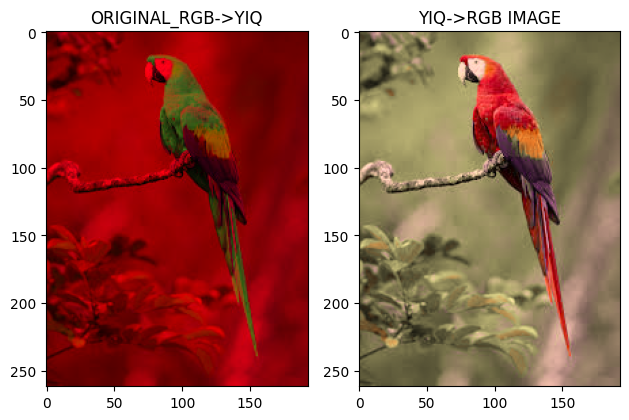

In [7]:
yiq_img = transformRGB2YIQ(img)
rgb_img = transformYIQ2RGB(yiq_img)


fig, ax = plt.subplots(1,2)
ax[0].imshow(yiq_img)
ax[0].set_title("ORIGINAL_RGB->YIQ")
ax[1].imshow(rgb_img)
ax[1].set_title("YIQ->RGB IMAGE")
plt.tight_layout()
plt.show()

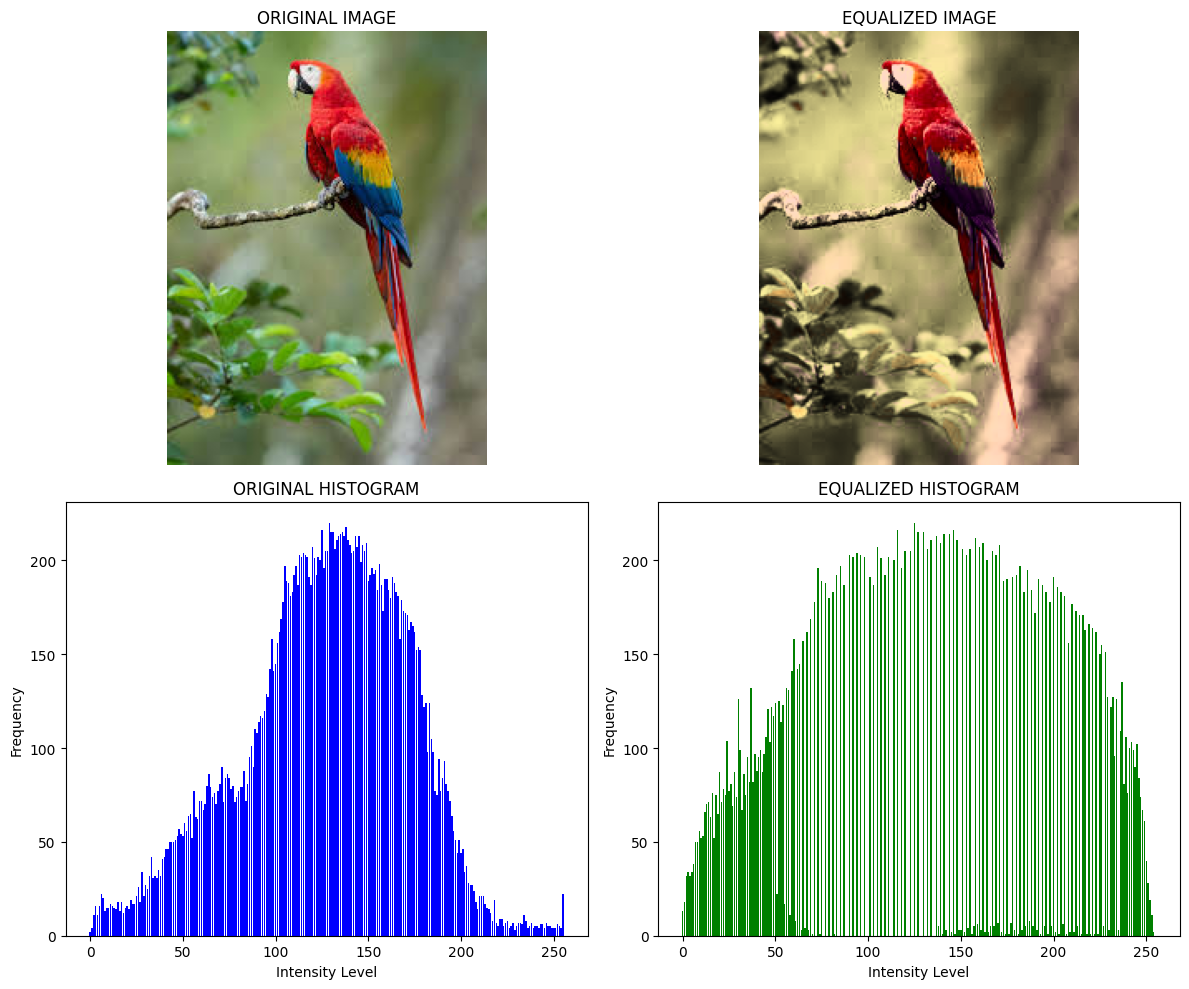

In [8]:

#4.4

def histogramEqualize(imOrig:np.ndarray)->tuple[np.ndarray, np.ndarray, np.ndarray]:
	"""""Equalizes the histogram of an image

	Args:
		imOrig (np.ndarray): Original Image

	Returns:
		imgEq (np.ndarray): Equalized Image
		histOrg (np.ndarray): Original Histogram
		histEq (np.ndarray): Equalized Histogram
	"""""
	histOrg = calHist(imOrig)
	image_cum = calCum(histOrg)
	LUT = np.round(image_cum/image_cum[-1]*255).astype(np.uint8) # LookUpTable for each intensity value
	
	if isGray(imOrig):
		imgEq = LUT[np.clip(np.round(imOrig * 255), 0, 255).astype(np.uint8)]/255
	else:
		yiq_img = transformRGB2YIQ(imOrig)
		yiq_img[:,:,0] = LUT[np.clip(np.round(yiq_img[:,:,0] * 255), 0, 255).astype(np.uint8)]/255
		imgEq = transformYIQ2RGB(yiq_img)
	histEq = calHist(imgEq)
	return imgEq, histOrg, histEq
	

def calHist(img:np.ndarray)->np.ndarray:
	"""_summary_

	Args:
		img (np.ndarray): an image in RGB or GRAY_SCALE

	Returns:
		np.ndarray: a histogram of the image 
	"""
	if isGray(img):
		img_flat = np.clip(np.round(img.ravel() * 255), 0, 255).astype(np.uint8)
	else:
		y = transformRGB2YIQ(img)[:, :, 0]
		img_flat = np.clip(np.round(y * 255), 0, 255).astype(np.uint8)

	hist = np.zeros(256)
	for pix in img_flat:
		hist[pix] +=1
	return hist

def calCum(hist:np.ndarray)->np.ndarray:
    return np.cumsum(hist)

def isGray(img:np.ndarray)->bool:
    return img.ndim == 2


imgEq, histOrg, histEq = histogramEqualize(img)
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

# Original image
ax[0, 0].imshow(img)
ax[0, 0].set_title("ORIGINAL IMAGE")
ax[0, 0].axis('off')

# Equalized image
ax[0, 1].imshow(imgEq)
ax[0, 1].set_title("EQUALIZED IMAGE")
ax[0, 1].axis('off')

# Original histogram (bar chart)
ax[1, 0].bar(range(256), histOrg, color='blue')
ax[1, 0].set_title("ORIGINAL HISTOGRAM")
ax[1, 0].set_xlabel("Intensity Level")
ax[1, 0].set_ylabel("Frequency")

# Equalized histogram (bar chart)
ax[1, 1].bar(range(256), histEq, color='green')
ax[1, 1].set_title("EQUALIZED HISTOGRAM")
ax[1, 1].set_xlabel("Intensity Level")
ax[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [9]:

# 4.5 a function that perform optimal quantization of given grayscale or RGB image.



def quantizeImage(imOrig:np.ndarray, nQuant:int, nIter:int)->tuple[List[np.ndarray], list[float]]:
	"""Quantized an image in to **nQuant** colors
		on RGB the quantization is performed on the Y channel of the YIQ color space, and then converted back to RGB
		if the image is in GRAY_SCALE the quantization is performed on the image itself
	Args:
		imOrig (np.ndarray): The original image (RGB or Gray scale)
		nQuant (int): The number of colors to quantize the image to
		nIter (int): The number of iterations for the k-means algorithm

	Returns:
		tuple[List[np.ndarray], list[float]]: A tuple containing the quantized images and the distortion values
	"""
 
	if nQuant <= 0 or nIter <= 0:
		print("nQuant and nIter must be positive integers")
		return [imOrig], []

	hist = calHist(imOrig)
 
	# we need to find z: borders which divide the histograms into segments, while z is nQuant+1 because we need to include the 0 and 255 values as well
	# and q: values that each segement will be quantized to, which is the mean of the segment
	z = np.zeros(nQuant+1)
	q = np.zeros(nQuant)
	
	# initialize z with equal segments
	for i in range(z.size -1):
		z[i+1] = 255/nQuant + z[i]
	# initialize q with the mean of each segment
	for i in range(q.size):
		left = int(z[i])
		right = int(z[i+1])

		segment_hist = hist[left:right+1]
		intensity_values = np.arange(left, right+1)
		if segment_hist.sum() == 0:
			q[i] = (left + right) / 2
		else:
			q[i] = np.sum(segment_hist * intensity_values) / np.sum(segment_hist)

		quanitized_images = []
		errors = []
		for i in range(nIter):
			# initialize q with the mean of each segment
			for i in range(q.size):
				left = int(z[i])
				right = int(z[i+1])

				segment_hist = hist[left:right+1]
				intensity_values = np.arange(left, right+1)
				if segment_hist.sum() == 0:
					q[i] = (left + right) / 2
				else:
					q[i] = np.sum(segment_hist * intensity_values) / np.sum(segment_hist)
			iter_error = 0
			# calculate the error of the current quantization
			for i in range(q.size):
				left = int(z[i])
				right = int(z[i+1])
				segment_hist = hist[left:right+1]
				intensity_values = np.arange(left, right+1)
				iter_error += np.sum(segment_hist * (intensity_values - q[i])**2)
			errors.append(iter_error)
		# create the quantized image
			if isGray(imOrig):
				img_quantized = np.zeros_like(imOrig)
				for i in range(q.size):
					left = int(z[i])
					right = int(z[i+1])
					img_quantized[np.logical_and(imOrig >= left/255, imOrig < right/255)] = q[i]/255
			else:
				yiq_img = transformRGB2YIQ(imOrig)
				img_quantized = np.zeros_like(imOrig)
				for i in range(q.size):
					left = int(z[i])
					right = int(z[i+1])
					mask = np.logical_and(yiq_img[:,:,0] >= left/255, yiq_img[:,:,0] < right/255)
					yiq_img[:,:,0][mask] = q[i]/255
				img_quantized = transformYIQ2RGB(yiq_img)
			quanitized_images.append(img_quantized)
		# update z
			for j in range(nQuant-1):
				z[j] = (q[j] + q[j+1]) / 2

		return quanitized_images, errors

def plot_quant_results(quantized_images, errors):
    n_imgs = len(quantized_images)
    total_plots = n_imgs + 1  # +1 for error plot

    cols = 4
    rows = int(np.ceil(total_plots / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.5 * rows))
    axes = np.array(axes).ravel()

    # show all quantized images
    for i, im in enumerate(quantized_images):
        if im.ndim == 2:
            axes[i].imshow(im, cmap="gray")
        else:
            axes[i].imshow(im)
        axes[i].set_title(f"Iter {i+1}\n Error: {errors[i]:.2f}")
        axes[i].axis("off")

    # last subplot: error curve
    err_ax = axes[n_imgs]
    err_ax.plot(errors, marker="o")
    err_ax.set_title("Error per Iteration")
    err_ax.set_xlabel("Iteration")
    err_ax.set_ylabel("Error")
    err_ax.grid(True, alpha=0.3)

    # hide any extra empty subplots
    for j in range(total_plots, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()



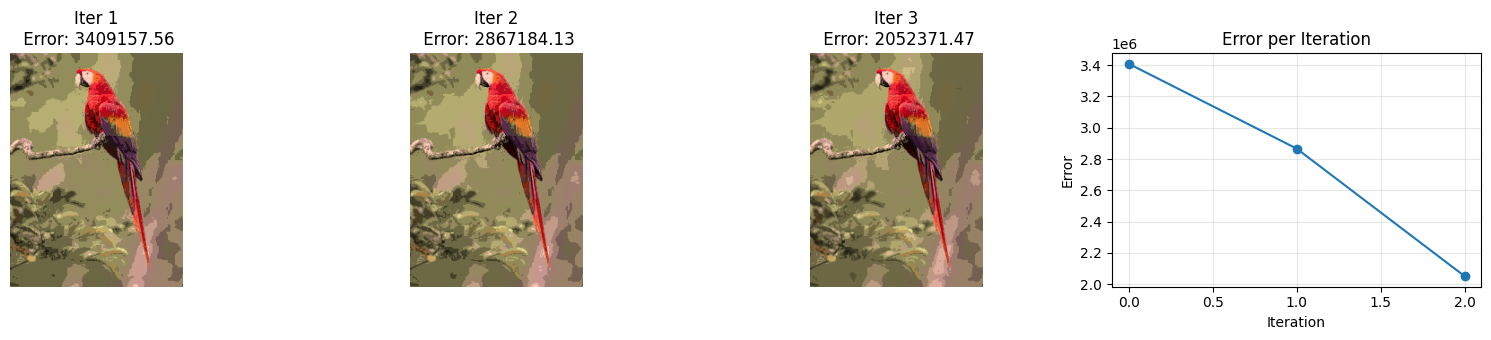

True

In [10]:
images, errors = quantizeImage(img, 6, 3)
plot_quant_results(images, errors)
first_img = images[0]  # first quantized image

# convert from float [0,1] RGB to uint8 BGR for OpenCV save
to_save = (np.clip(first_img, 0, 1) * 255).astype(np.uint8)
to_save_bgr = cv2.cvtColor(to_save, cv2.COLOR_RGB2BGR)

cv2.imwrite("../images/quantized_first.png", to_save_bgr)

In [11]:
from __future__ import print_function
from __future__ import division
import cv2 as cv

# 4.6 Gamma correction

def gammaDisplay(img_path:str, rep:int)->None:
	"""GUI for gamma correction
	Args:
		img_path (str): The path to the image
		rep (int): GRAY_SCALE(1) or RGB(2)
		returns: None
"""
	img = imReadAndConvert(img_path, rep)
 
	gamma_slider_max = 200
	title_window = 'Gamma Correction'
	trackbar_name = "Gamma x 100"
	cv.namedWindow(title_window)

	def on_trackbar(val):
			gamma = max(val, 1) / 100.0
			dst = np.power(img, gamma)
			dst = np.clip(dst, 0, 1)
			cv.imshow(title_window, (dst * 255).astype(np.uint8))

	cv.createTrackbar(trackbar_name, title_window, 100, gamma_slider_max, on_trackbar)
	on_trackbar(100)
	cv.waitKey(0)
	cv.destroyAllWindows()




In [13]:
gammaDisplay(IMAGE_NAME, 1)